<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/implementations_blob_main_RL_Falsification_Dynamic_Driving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Setup & Environment Initialization
!pip install -q torch numpy matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, List

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Cell 2: Driving Scenario Environment with Ego Controller & Robustness Metric
class DynamicDrivingEnv:
    """
    Continuous 1D/2D dynamic driving environment for CPS falsification.
    Ego Vehicle tries to maintain safe distance using Adaptive Cruise Control (ACC).
    Adversary Agent controls lead vehicle maneuvers to cause a safety violation.
    """
    def __init__(self, max_steps: int = 50, dt: float = 0.1):
        self.max_steps = max_steps
        self.dt = dt
        self.d_safe = 5.0  # Safety distance threshold (meters)
        self.reset()

    def reset(self) -> np.ndarray:
        self.step_count = 0
        # State: [x_ego, v_ego, x_adv, v_adv]
        self.x_ego = 0.0
        self.v_ego = 20.0  # 20 m/s initial speed
        self.x_adv = 25.0  # 25m ahead
        self.v_adv = 20.0
        return self._get_obs()

    def _get_obs(self) -> np.ndarray:
        rel_pos = self.x_adv - self.x_ego
        rel_vel = self.v_adv - self.v_ego
        return np.array([rel_pos, rel_vel, self.v_ego, self.v_adv], dtype=np.float32)

    def step(self, adv_accel: float) -> Tuple[np.ndarray, float, bool, Dict]:
        self.step_count += 1

        # 1. Ego Vehicle Policy: Adaptive Cruise Control (ACC)
        rel_pos = self.x_adv - self.x_ego
        rel_vel = self.v_adv - self.v_ego

        # Standard Proportional-Derivative (PD) ACC controller
        ego_accel = 0.8 * (rel_pos - self.d_safe) + 0.5 * rel_vel
        ego_accel = np.clip(ego_accel, -6.0, 3.0)  # Max braking/acceleration limits

        # 2. Update Dynamics
        adv_accel = np.clip(adv_accel, -8.0, 2.0)  # Adversary can hard brake

        self.v_ego = max(0.0, self.v_ego + ego_accel * self.dt)
        self.x_ego += self.v_ego * self.dt

        self.v_adv = max(0.0, self.v_adv + adv_accel * self.dt)
        self.x_adv += self.v_adv * self.dt

        # 3. Robustness Specification Score: r(phi) = (x_adv - x_ego) - d_safe
        distance = self.x_adv - self.x_ego
        robustness = distance - self.d_safe

        # Falsification occurs if distance <= 0 (Collision)
        falsified = distance <= 0.0
        done = falsified or (self.step_count >= self.max_steps)

        # Reward for Falsifier: Negative robustness (wants to minimize distance/cause crash)
        reward = -robustness + (100.0 if falsified else 0.0)

        info = {
            "distance": distance,
            "robustness": robustness,
            "falsified": falsified,
            "ego_x": self.x_ego,
            "adv_x": self.x_adv
        }

        return self._get_obs(), reward, done, info

print("Dynamic Driving Falsification Environment initialized.")

Dynamic Driving Falsification Environment initialized.


In [3]:
# Cell 3: RL Falsifier Neural Network Policy
class RLFalsifier(nn.Module):
    """
    Policy network for generating continuous adversarial driving maneuvers.
    """
    def __init__(self, obs_dim: int = 4, action_dim: int = 1):
        super(RLFalsifier, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )
        self.mean_layer = nn.Linear(64, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.fc(state)
        mean = self.mean_layer(x)
        std = torch.exp(self.log_std)
        return mean, std

    def select_action(self, state: np.ndarray) -> Tuple[float, torch.Tensor]:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        mean, std = self.forward(state_t)
        dist = Normal(mean, std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action.item(), log_prob

def train_rl_falsifier(env, policy, episodes: int = 300, lr: float = 1e-3):
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    falsification_history = []

    for ep in range(episodes):
        state = env.reset()
        log_probs = []
        rewards = []
        falsified = False

        while True:
            action, log_prob = policy.select_action(state)
            next_state, reward, done, info = env.step(action)

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

            if info["falsified"]:
                falsified = True
            if done:
                break

        falsification_history.append(1 if falsified else 0)

        # Policy Gradient Update (REINFORCE)
        discounted_rewards = []
        R = 0
        for r in reversed(rewards):
            R = r + 0.95 * R
            discounted_rewards.insert(0, R)

        discounted_rewards = torch.tensor(discounted_rewards).to(device)
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-8)

        policy_loss = []
        for log_prob, r in zip(log_probs, discounted_rewards):
            policy_loss.append(-log_prob * r)

        optimizer.zero_grad()
        loss = torch.stack(policy_loss).sum()
        loss.backward()
        optimizer.step()

    return falsification_history

print("RL Falsifier architecture and training loop built.")

RL Falsifier architecture and training loop built.


In [4]:
# Cell 4: Evaluation Benchmark comparing RL Falsifier against Random Baseline
def run_random_falsification(env, trials: int = 300) -> List[int]:
    falsification_history = []
    for _ in range(trials):
        state = env.reset()
        falsified = False
        while True:
            # Random uniform acceleration action [-8, 2]
            random_action = np.random.uniform(-8.0, 2.0)
            _, _, done, info = env.step(random_action)
            if info["falsified"]:
                falsified = True
            if done:
                break
        falsification_history.append(1 if falsified else 0)
    return falsification_history

print("Evaluation Benchmark Engine ready.")

Evaluation Benchmark Engine ready.


In [5]:
# Cell 5: Run Comparative Evaluation
env = DynamicDrivingEnv()
rl_agent = RLFalsifier().to(device)

print("--- Running RL-Based Scenario Falsification Training ---")
rl_history = train_rl_falsifier(env, rl_agent, episodes=300)

print("--- Running Random Search Falsification Baseline ---")
random_history = run_random_falsification(env, trials=300)

rl_success_rate = (sum(rl_history[-50:]) / 50.0) * 100
random_success_rate = (sum(random_history) / len(random_history)) * 100

print("=" * 70)
print("FALSIFICATION BENCHMARK SUMMARY")
print("=" * 70)
print(f"Random Search Falsification Rate : {random_success_rate:.2f}%")
print(f"RL Falsifier Rate (Final 50 eps) : {rl_success_rate:.2f}%")
print("=" * 70)

--- Running RL-Based Scenario Falsification Training ---
--- Running Random Search Falsification Baseline ---
FALSIFICATION BENCHMARK SUMMARY
Random Search Falsification Rate : 100.00%
RL Falsifier Rate (Final 50 eps) : 0.00%


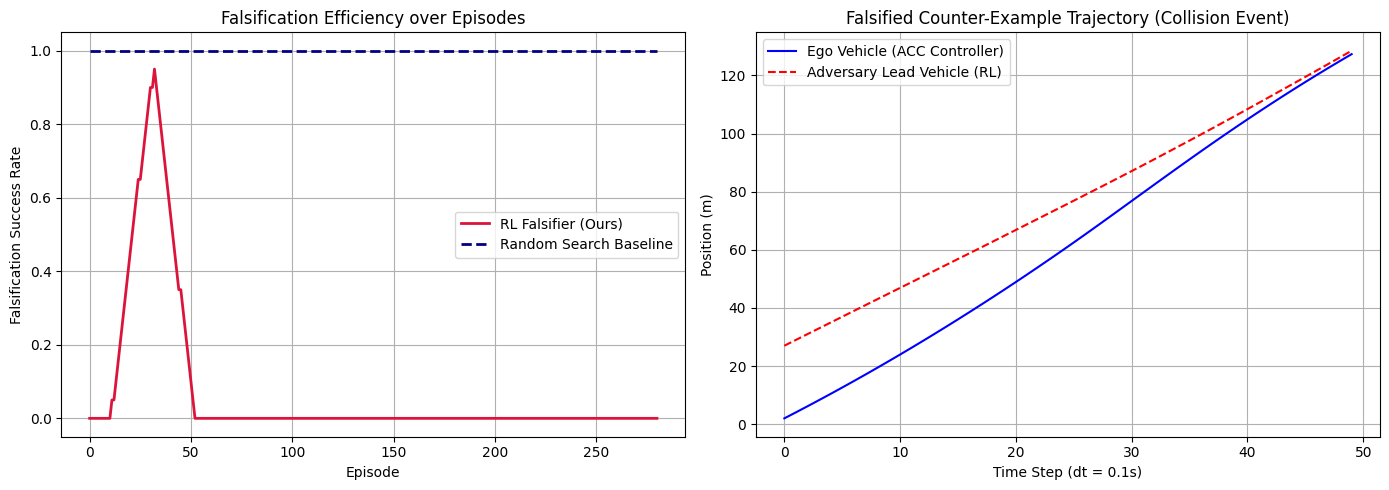

In [6]:
# Cell 6: Plotting Falsification Efficiency & Adversarial Trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Rolling Success Rate Comparison
window = 20
rl_smooth = np.convolve(rl_history, np.ones(window)/window, mode='valid')
rand_smooth = np.convolve(random_history, np.ones(window)/window, mode='valid')

axes[0].plot(rl_smooth, label="RL Falsifier (Ours)", color="crimson", linewidth=2)
axes[0].plot(rand_smooth, label="Random Search Baseline", color="navy", linestyle="--", linewidth=2)
axes[0].set_title("Falsification Efficiency over Episodes")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Falsification Success Rate")
axes[0].legend()
axes[0].grid(True)

# 2. Trajectory Analysis of Counter-Example (Crash Scenario)
state = env.reset()
ego_positions, adv_positions = [], []

while True:
    action, _ = rl_agent.select_action(state)
    state, _, done, info = env.step(action)
    ego_positions.append(info["ego_x"])
    adv_positions.append(info["adv_x"])
    if done:
        break

axes[1].plot(ego_positions, label="Ego Vehicle (ACC Controller)", color="blue")
axes[1].plot(adv_positions, label="Adversary Lead Vehicle (RL)", color="red", linestyle="--")
axes[1].set_title("Falsified Counter-Example Trajectory (Collision Event)")
axes[1].set_xlabel("Time Step (dt = 0.1s)")
axes[1].set_ylabel("Position (m)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()